In [1]:
#STEP-01 Loading all libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split # spliting data into training and testing sets
from sklearn.ensemble import RandomForestClassifier, IsolationForest # Random Forest classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Check accuracy score 

In [2]:
#STEP-02
# Loading dataset & display the first few rows of the dataframe
df = pd.read_csv('SDN20_Shuffled.csv')

In [3]:
# Assuming our labels are in a column named 'multilabel' cosidering normal as 0 and rest anomalous as 1
#df['project'] = df['project'].apply(lambda x: 0 if x == 'BRCA' else 1)
df.shape

(205167, 78)

In [4]:
df.columns

Index(['Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Size Avg', 'Bwd

In [5]:
df.fillna(0, inplace=True)
df_y=df['multilabel']
df_x=df.drop(labels=['multilabel'], axis=1)

In [6]:
pd.options.display.max_rows = 100
df_x.dtypes

Protocol               int64
Flow Duration          int64
Tot Fwd Pkts           int64
Tot Bwd Pkts           int64
TotLen Fwd Pkts        int64
TotLen Bwd Pkts        int64
Fwd Pkt Len Max        int64
Fwd Pkt Len Min        int64
Fwd Pkt Len Mean     float64
Fwd Pkt Len Std      float64
Bwd Pkt Len Max        int64
Bwd Pkt Len Min        int64
Bwd Pkt Len Mean     float64
Bwd Pkt Len Std      float64
Flow Byts/s          float64
Flow Pkts/s          float64
Flow IAT Mean        float64
Flow IAT Std         float64
Flow IAT Max           int64
Flow IAT Min           int64
Fwd IAT Tot            int64
Fwd IAT Mean         float64
Fwd IAT Std          float64
Fwd IAT Max            int64
Fwd IAT Min            int64
Bwd IAT Tot            int64
Bwd IAT Mean         float64
Bwd IAT Std          float64
Bwd IAT Max            int64
Bwd IAT Min            int64
Fwd PSH Flags          int64
Bwd PSH Flags          int64
Fwd URG Flags          int64
Bwd URG Flags          int64
Fwd Header Len

In [7]:
df_y=pd.DataFrame(df_y)
df_y

,multilabel
0,DDoS
1,DDoS
2,normal
3,normal
4,Probe
...,...
205162,Probe
205163,normal
205164,normal
205165,Probe


In [8]:
df_y.loc[df_y['multilabel'] == 'normal', 'multilabel'] = 0
df_y.loc[df_y['multilabel'] != 0, 'multilabel'] = 1
df_y['multilabel']=df_y['multilabel'].astype(int)

In [9]:
df_y

,multilabel
0,1
1,1
2,0
3,0
4,1
...,...
205162,1
205163,0
205164,0
205165,1


In [10]:
#find categorical data
df_x.nunique()
#maybe categorical: Protocol;Fwd PSH Flags; Bwd PSH Flags; URG Flags; Bwd URG Flags
#ignoring this for now

Protocol                 3
Flow Duration        67502
Tot Fwd Pkts           530
Tot Bwd Pkts           682
TotLen Fwd Pkts       5289
TotLen Bwd Pkts       7495
Fwd Pkt Len Max       2103
Fwd Pkt Len Min         76
Fwd Pkt Len Mean      8479
Fwd Pkt Len Std      10133
Bwd Pkt Len Max       2950
Bwd Pkt Len Min         64
Bwd Pkt Len Mean     10317
Bwd Pkt Len Std      12487
Flow Byts/s          84729
Flow Pkts/s          73249
Flow IAT Mean        74942
Flow IAT Std         72562
Flow IAT Max         36014
Flow IAT Min         14150
Fwd IAT Tot          31575
Fwd IAT Mean         42164
Fwd IAT Std          43915
Fwd IAT Max          30657
Fwd IAT Min          11633
Bwd IAT Tot          34144
Bwd IAT Mean         47609
Bwd IAT Std          45405
Bwd IAT Max          31981
Bwd IAT Min          14196
Fwd PSH Flags            1
Bwd PSH Flags            2
Fwd URG Flags            1
Bwd URG Flags            1
Fwd Header Len         597
Bwd Header Len        1008
Fwd Pkts/s           66303
B

In [11]:
#moving to numpy as it is easier to check columns
np_x=df_x.to_numpy()
identical=np.all(np_x == np_x[0,:], axis = 0)
identical #True means there are some columns that must be dropped

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True, False, False, False,
       False,  True,  True,  True,  True,  True,  True, False, False,
       False, False,  True, False, False,  True, False, False, False,
       False, False, False, False, False])

In [12]:
to_be_deleted=np.where(identical==True)
to_be_deleted

(array([30, 32, 33, 48, 49, 50, 55, 56, 57, 58, 59, 60, 65, 68],
       dtype=int64),)

In [13]:
#deleting column, back to pandas as it is easier
data_pd=pd.DataFrame(np_x)

In [14]:
data_pd.drop(data_pd.columns[to_be_deleted[0]], inplace=True, axis=1)

In [15]:
#back to numpy and normalize
np_x=data_pd.to_numpy()
# normalize each column by subtracting its mean and dividing by its standard deviation
col_means = np.mean(np_x, axis=0)

data_normalized = (np_x - col_means) / np.std(np_x, axis=0)

In [16]:
# STEP-01: 
# Spliting data into training and testing sets

# Define X and y
X = df[['Protocol',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd Byts/b Avg',
 'Fwd Pkts/b Avg',
 'Fwd Blk Rate Avg',
 'Bwd Byts/b Avg',
 'Bwd Pkts/b Avg',
 'Bwd Blk Rate Avg',
 'Subflow Fwd Pkts',
 'Subflow Fwd Byts',
 'Subflow Bwd Pkts',
 'Subflow Bwd Byts',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Active Max',
 'Active Min',
 'Idle Mean',
 'Idle Std',
 'Idle Max',
 'Idle Min']]  # Features
y = df['multilabel']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [17]:
# Start of Isolation Forest model
# Step:02 Random Forest Classifier model with default parameters

# instantiate the classifier 
rfc = RandomForestClassifier(random_state=0)

# fit the model
rfc.fit(X_train, y_train)

# Predict the Test set results
y_pred = rfc.predict(X_test)

# Find important features with Random Forest model
# create the classifier with n_estimators = 100
clf = RandomForestClassifier(n_estimators=100, random_state=0)

# fit the model to the training set
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [18]:
# STEP-03
# Performance Metrices
y_pred_train = rfc.predict(X_train)
y_pred_test = rfc.predict(X_test)

# View accuracy score 
# Sprint('Model accuracy score : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))
# Calculate metrics for the training set
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='weighted')
recall_train = recall_score(y_train, y_pred_train, average='weighted')
f1_train = f1_score(y_train, y_pred_train, average='weighted')

# Calculate metrics for the testing set
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='weighted')
recall_test = recall_score(y_test, y_pred_test, average='weighted')
f1_test = f1_score(y_test, y_pred_test, average='weighted')

print(f'Training Accuracy: {accuracy_train}')
print(f'Training Precision: {precision_train}')
print(f'Training Recall: {recall_train}')
print(f'Training F1-score: {f1_train}')
print()

print(f'Testing Accuracy: {accuracy_test}')
print(f'Testing Precision: {precision_test}')
print(f'Testing Recall: {recall_test}')
print(f'Testing F1-score: {f1_test}')

Training Accuracy: 0.9996508100479409
Training Precision: 0.9996490181517197
Training Recall: 0.9996508100479409
Training F1-score: 0.9996282199198261

Testing Accuracy: 0.9981537825303518
Testing Precision: 0.9979608464255493
Testing Recall: 0.9981537825303518
Testing F1-score: 0.9980406546572925


In [19]:
# Check for missing values and handle them appropriately
if X.isnull().sum().any() or y.isnull().sum().any():
    X = X.fillna(X.mean())  # Example: filling missing values with the mean
    y = y.fillna(y.mode()[0])  # Example: filling missing values with the mode  

# Convert y to the format expected by IsolationForest if needed
y = y.apply(lambda x: -1 if x == 0 else 1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
# Start of Isolation Forest model
#STEP-02
# Fit the Isolation Forest model on the training data
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(X_train)
model.fit(X_test)

C:\Users\Setha\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\Setha\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


IsolationForest(contamination=0.1, random_state=42)

In [21]:
#STEP-03
# Predict anomalies on the training data
y_train_pred = model.predict(X_train)

# Step 6: Predict anomalies on the testing data
y_test_pred = model.predict(X_test)

# Step 7: Calculate accuracy and other metrics for training data
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Step 8: Calculate accuracy and other metrics for testing data
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Print the results for training data
# print('Model accuracy score : {0:0.4f}'. format(accuracy_score(y_test, y_test_pred)))
print('Training Scores:')
print(f'Accuracy: {train_accuracy}')
print(f'Precision: {train_precision}')
print(f'Recall: {train_recall}')
print(f'F1 Score: {train_f1}')
print()

# Print the results for testing data
print('Testing Scores:')
print(f'Accuracy: {test_accuracy}')
print(f'Precision: {test_precision}')
print(f'Recall: {test_recall}')
print(f'F1 Score: {test_f1}')

Training Scores:
Accuracy: 0.8999275846702317
Precision: 1.0
Recall: 0.8999275846702317
F1 Score: 0.9473283002272227

Testing Scores:
Accuracy: 0.9000016246689737
Precision: 1.0
Recall: 0.9000016246689737
F1 Score: 0.9473693211454761


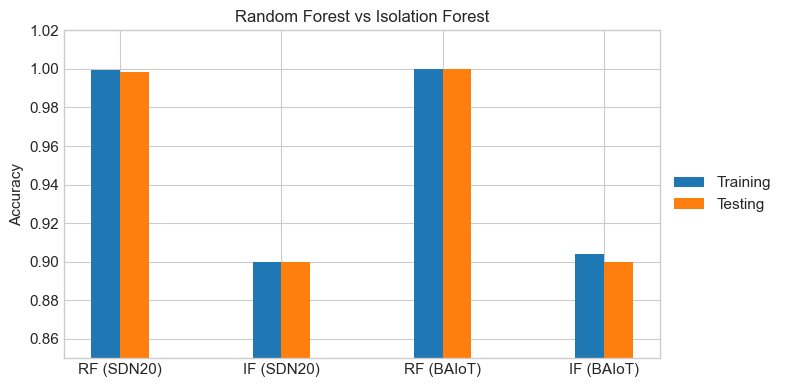

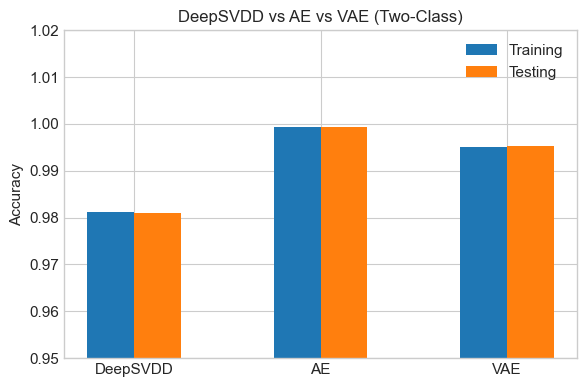

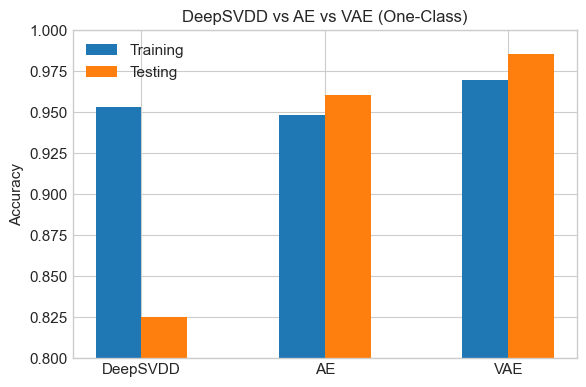

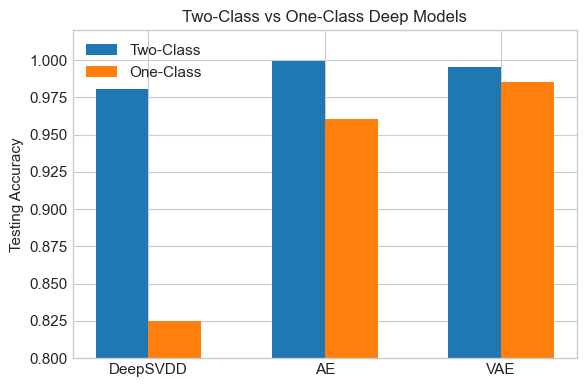

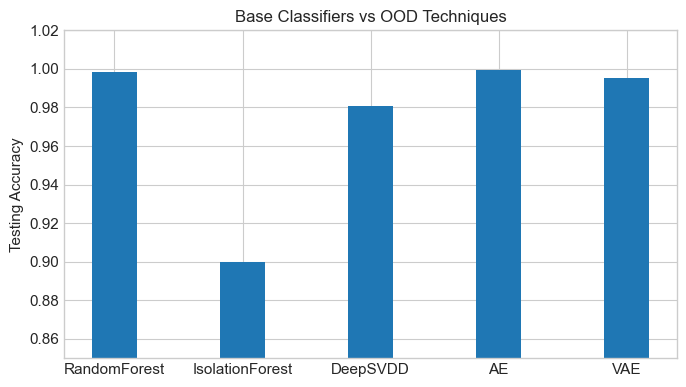

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11
})

# 1. Random Forest vs Isolation Forest

models = ["RF (SDN20)", "IF (SDN20)", "RF (BAIoT)", "IF (BAIoT)"]

train = [0.99965081, 0.899927585, 1.0, 0.903941917]
test = [0.998153783, 0.900001625, 1.0, 0.9]

x = np.arange(len(models)) * 1.4
width = 0.25

plt.figure(figsize=(8,4))

plt.bar(x - width/2, train, width, label="Training")
plt.bar(x + width/2, test, width, label="Testing")

plt.xticks(x, models)

plt.ylabel("Accuracy")
plt.title("Random Forest vs Isolation Forest")

plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.ylim(0.85,1.02)

plt.tight_layout()
plt.savefig("rf_vs_if.png", dpi=300)
plt.show()


# 2. DeepSVDD vs AE vs VAE (Two-Class)

models = ["DeepSVDD", "AE", "VAE"]

train = [0.9811, 0.999348, 0.995]
test = [0.9809, 0.999318, 0.9952]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(6,4))

plt.bar(x - width/2, train, width, label="Training")
plt.bar(x + width/2, test, width, label="Testing")

plt.xticks(x, models)

plt.ylabel("Accuracy")
plt.title("DeepSVDD vs AE vs VAE (Two-Class)")

plt.legend()
plt.ylim(0.95,1.02)

plt.tight_layout()
plt.savefig("deep_two_class.png", dpi=300)
plt.show()


# 3. DeepSVDD vs AE vs VAE (One-Class)

models = ["DeepSVDD", "AE", "VAE"]

train = [0.95321, 0.948231, 0.97]
test = [0.825242, 0.96078, 0.9855]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(6,4))

plt.bar(x - width/2, train, width, label="Training")
plt.bar(x + width/2, test, width, label="Testing")

plt.xticks(x, models)

plt.ylabel("Accuracy")
plt.title("DeepSVDD vs AE vs VAE (One-Class)")

plt.legend()
plt.ylim(0.80,1.0)

plt.tight_layout()
plt.savefig("deep_one_class.png", dpi=300)
plt.show()


# 4. Deep Models: Two-Class vs One-Class

models = ["DeepSVDD", "AE", "VAE"]

two_class = [0.9809, 0.999318, 0.9952]
one_class = [0.825242, 0.96078, 0.9855]

x = np.arange(len(models))
width = 0.30

plt.figure(figsize=(6,4))

plt.bar(x - width/2, two_class, width, label="Two-Class")
plt.bar(x + width/2, one_class, width, label="One-Class")

plt.xticks(x, models)

plt.ylabel("Testing Accuracy")
plt.title("Two-Class vs One-Class Deep Models")

plt.legend()
plt.ylim(0.80,1.02)

plt.tight_layout()
plt.savefig("two_class_vs_one_class.png", dpi=300)
plt.show()



# 5. Base Classifiers vs OOD Techniques

models = ["RandomForest", "IsolationForest", "DeepSVDD", "AE", "VAE"]

acc = [0.998153783, 0.900001625, 0.9809, 0.999318, 0.9952]

x = np.arange(len(models))

plt.figure(figsize=(7,4))

plt.bar(x, acc, width=0.35)

plt.xticks(x, models)

plt.ylabel("Testing Accuracy")
plt.title("Base Classifiers vs OOD Techniques")

plt.ylim(0.85,1.02)

plt.tight_layout()
plt.savefig("base_vs_ood.png", dpi=300)
plt.show()